# Brain Flatmap

This notebook contains code to reproduce the brain flatmap.

In [ ]:
import cortex
import nibabel as nib
from src.paths import ROOT
from src.utils import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from src.brain_encoding.manage_encoding_results import ParticipantResults

In [ ]:
# run only once
# import cortex
# cortex.download_subject('fsaverage')

Done downloading to /var/folders/58/wcp587g90ng_jrcjxynmygj40000gn/T/tmp_bt8064t/fsaverage.tar.gz
Extracting subject fsaverage to /Users/anna/Documents/Code/scene-captions/scenes/share/pycortex/db


In [ ]:
# results = open_pickle(ROOT / 'results/encoding/encoding_by_model/kalm-pixtral.pkl')
# sign_mask = open_pickle(ROOT / 'results/encoding/significance_masks/kalm-pixtral.pkl')

results = open_pickle(ROOT / 'results/encoding/encoding_by_model/resnet-clip.pkl')
sign_mask = open_pickle(ROOT / 'results/encoding/significance_masks/resnet-clip.pkl')

p_res = ParticipantResults(participant=5, results=results, masks=sign_mask, significant_results_only=True)
accs = p_res.get_roi_accuracies_fsaverage(roi='all')

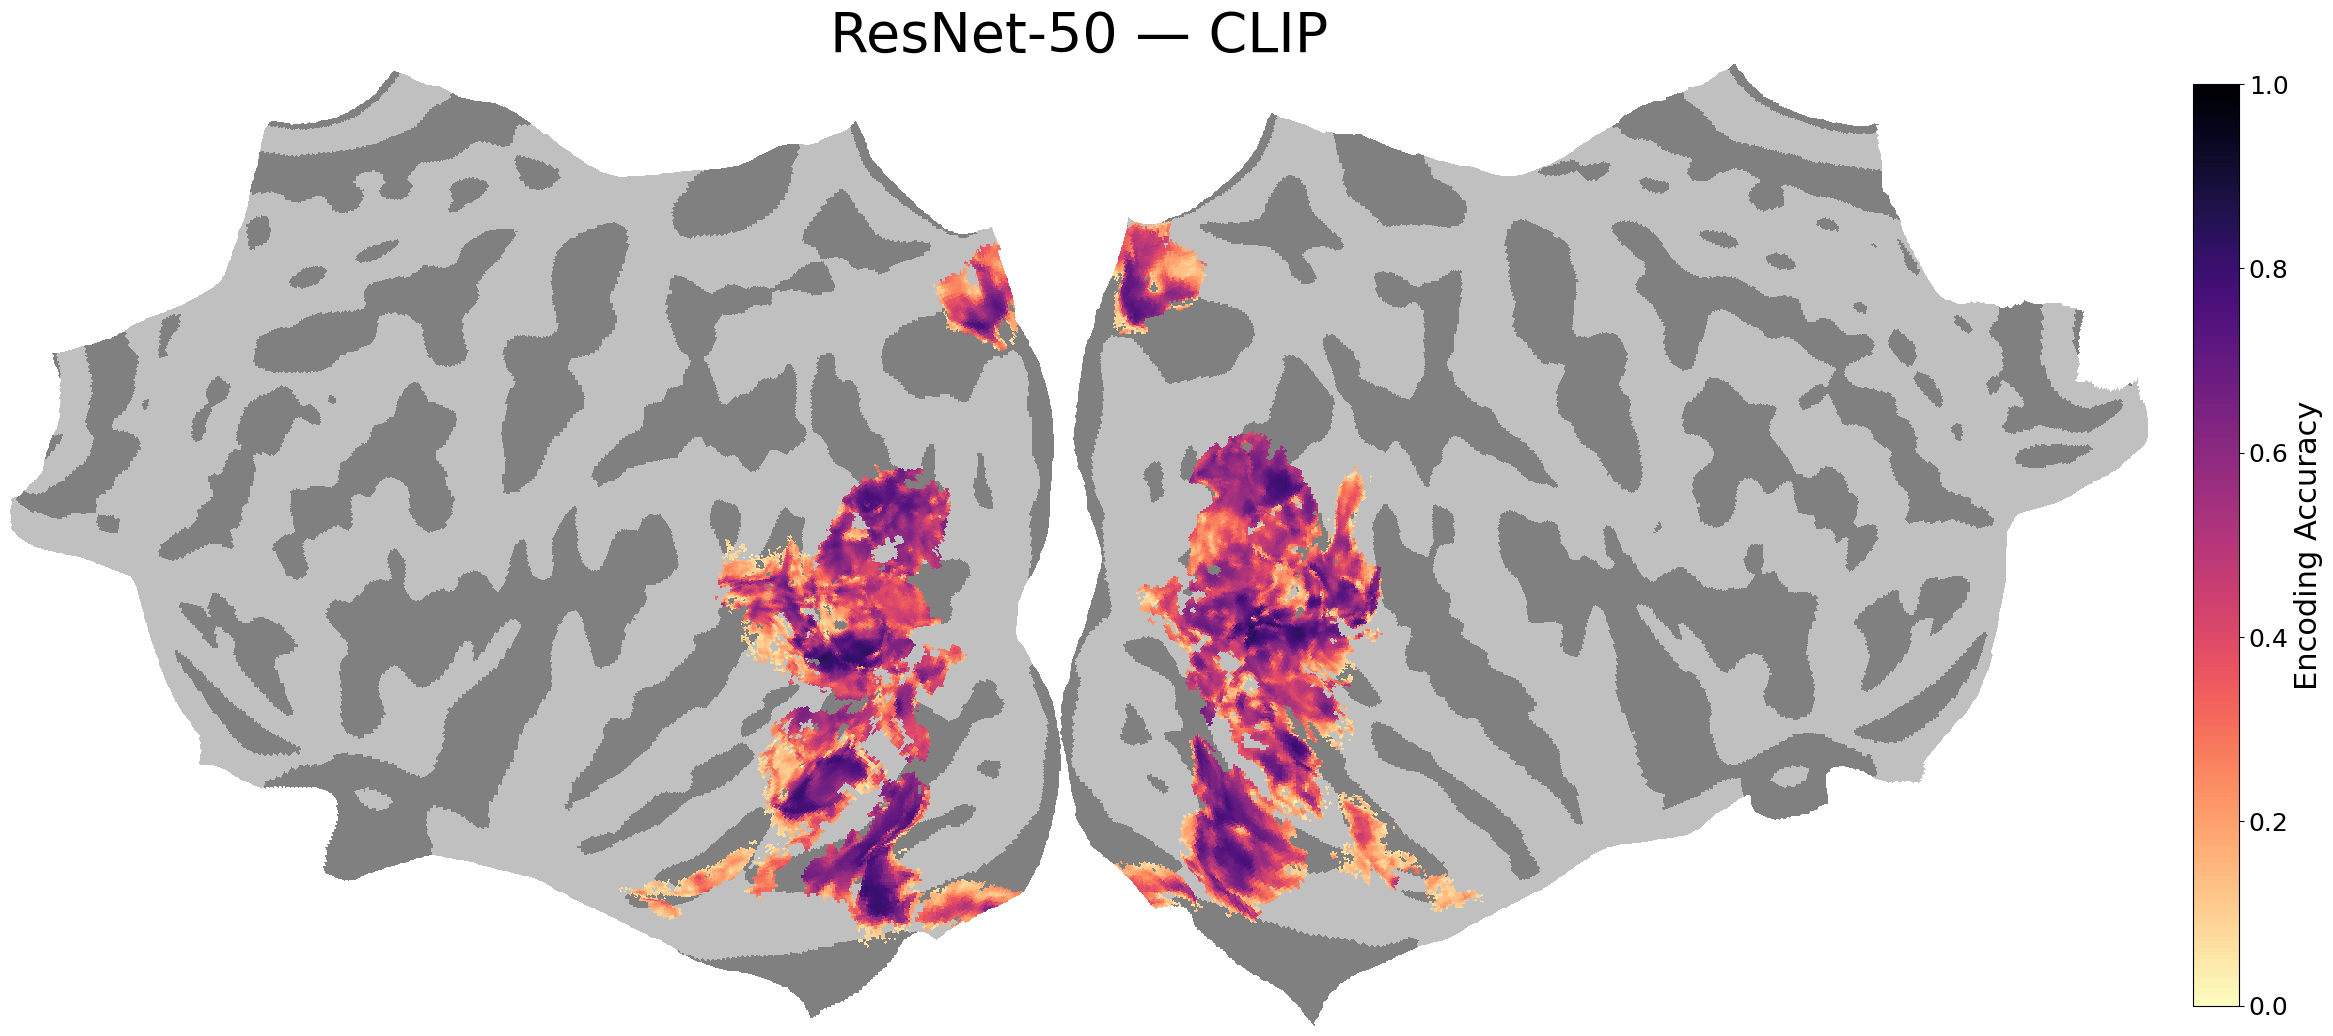

In [ ]:

def plot_vertices_with_curvature(vertices, title):
    vertex_data = cortex.Vertex(
        vertices,
        'fsaverage',
        cmap='magma_r',
        vmax=1
    )
    transparency_map = vertices != 0
    vert_w_curv = vertex_data.blend_curvature(
        transparency_map,
        threshold=0,
        brightness=0.5,
        contrast=0.25,
        smooth=20
    )

    fig = cortex.quickshow(
        vert_w_curv,
        with_curvature=False,
        with_rois=False,
        with_colorbar=False,
    )

    # Create a mappable that matches the data colormap
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap='magma_r')
    sm.set_array([])

    cbar = fig.colorbar(
    sm,
    ax=fig.axes,
    orientation='vertical',
    fraction=0.04,
    pad=0.02,
    shrink=0.9
    )
    
    cbar.ax.tick_params(labelsize=18)   
    cbar.set_label("Encoding Accuracy", fontsize=22)  

    plt.title(title, size=40)
    plt.savefig(ROOT / "results/plots" / f"flatmap_{title.split(' ')[0]}.pdf", bbox_inches="tight")
    plt.show()


plot_vertices_with_curvature(accs, title="ResNet-50 — CLIP")